✅ Data Loaded & Cleaned Successfully


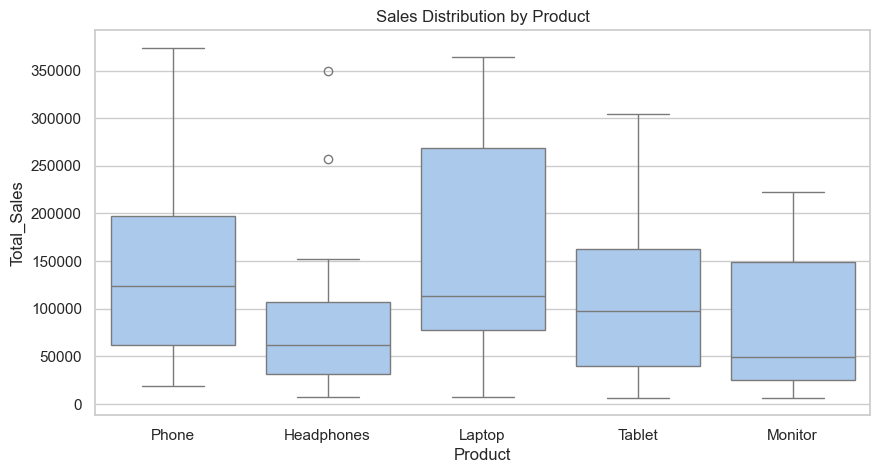

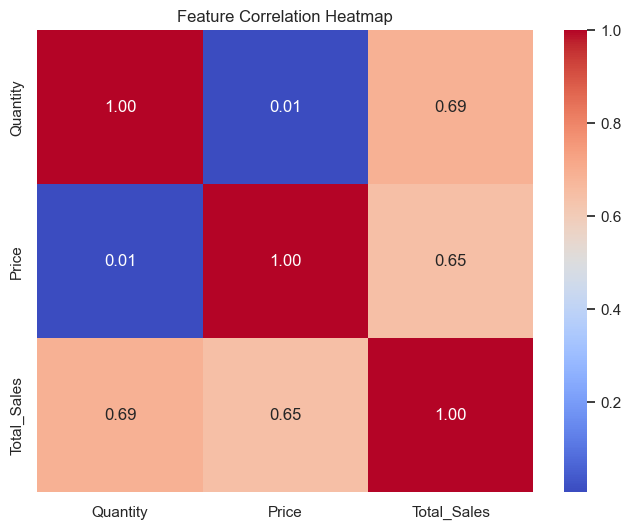

In [6]:
# %% [markdown]
# # 🚀 Week 6: Interactive Sales Dashboard
# **Objective:** Analyze sales trends using Statistical (Seaborn) and Interactive (Plotly) visualizations.

# %%
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Setup Styles
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 5)

# Load Data
df = pd.read_csv('sales_data.csv')

# Data Cleaning (Fill Missing Values)
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Convert Date
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

print("✅ Data Loaded & Cleaned Successfully")

# %% [markdown]
# ## 📊 Part 1: Statistical Analysis (Seaborn)
# **Goal:** Understand data distribution and correlation.

# %%
# 1. Price Distribution (Box Plot)
plt.figure()
sns.boxplot(x='Product', y='Total_Sales', data=df)
plt.title('Sales Distribution by Product')
plt.show()

# %%
# 2. Correlation Matrix (Heatmap)
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# %% [markdown]
# ## ✨ Part 2: Interactive Dashboard (Plotly)
# **Goal:** Explore trends with hover capabilities.

# %%
# 3. Interactive Sales Trend
if 'Date' in df.columns:
    daily_sales = df.groupby('Date')['Total_Sales'].sum().reset_index()
    fig = px.line(daily_sales, x='Date', y='Total_Sales', markers=True, 
                  title='<b>Daily Sales Trend</b> (Hover for Details)', template='plotly_white')
    fig.show()

# %%
# 4. Interactive Regional Split
if 'Region' in df.columns:
    fig = px.pie(df, names='Region', values='Total_Sales', hole=0.5,
                 title='<b>Sales Share by Region</b>')
    fig.show()